# GEOSPATIAL ANALYSIS OF EARTHQUAKE DISTRIBUTION IN JAPAN<a href="#GEOSPATIAL-ANALYSIS-OF-EARTHQUAKE-DISTRIBUTION-IN-JAPAN"
class="anchor-link">¶</a>

#### Name: Srijan Mukherjee<a href="#Name:-Srijan-Mukherjee" class="anchor-link">¶</a>

#### ID: 201939165<a href="#ID:-201939165" class="anchor-link">¶</a>

#### Module: Advance Geovisulation-Assignment 1<a href="#Module:-Advance-Geovisulation-Assignment-1"
class="anchor-link">¶</a>

## Context and Research Topic:<a href="#Context-and-Research-Topic:" class="anchor-link">¶</a>

#### Introduction:<a href="#Introduction:" class="anchor-link">¶</a>

Located at the meeting point of four major tectonic plates—the Pacific,
Philippine Sea, Eurasian, and North American plates—Japan is one of the
most seismically active places on Earth. About 20% of earthquakes with a
magnitude of 6.0 or higher occur in Japan due to its distinct geological
configuration (Headquarters for Earthquake Research Promotion, 2020).
This risk has serious repercussions, starting with the disastrous 2011
The Noto Peninsula earthquake (M7.5) in 2024 devastated coastal
communities in Ishikawa Prefecture, while the Tōhoku earthquake and
tsunami (M9.0) killed over 15,000 people and set off the Fukushima
nuclear disaster.

Numerous academic fields are involved in the study of Japanese
seismicity. Critical gaps in probabilistic seismic hazard assessment
(PSHA) were revealed when Lay et al. (2011) showed that the Tōhoku
rupture surpassed previous hazard models. Hashimoto et al. (2012)
highlighted the spatial extent of plate coupling along the Japan Trench
by mapping coseismic deformation using InSAR data. In a more recent
study, Nishimura (2021) identified areas of increased future rupture
potential in southwest Japan by analysing interseismic coupling rates
along the Nankai Trough. The ETAS (Epidemic Type Aftershock Sequence)
model, created by Ogata in 1988, is now a key tool for predicting
aftershock sequences after significant earthquakes in Japan.

According to Adger et al. (2005), vulnerability to seismic hazard is not
just physical; institutional capacity, building stock quality, and urban
density all influence the course of disasters. The necessity of
spatially explicit hazard communication was highlighted by Takabatake et
al. (2020), who specifically looked at evacuation behaviour in Japanese
coastal communities.

This assessment contributes to the larger objective of evidence-based
seismic risk communication by visualising the spatial and temporal
distribution of M≥5 earthquakes in Japan between 2015 and 2024 using
USGS catalogue data to investigate clustering patterns in relation to
tectonic plate boundaries, focal depth variation, and inter-period
density shifts.

In \[1\]:

    # Libraries
    %matplotlib inline
    import matplotlib
    matplotlib.rcParams['figure.dpi'] = 120

In \[2\]:

    import requests, warnings
    import pandas as pd
    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.colors import Normalize
    from scipy.stats import gaussian_kde
    import contextily as ctx
    import folium
    from folium.plugins import HeatMap, MarkerCluster, Fullscreen, MiniMap
    from branca.colormap import StepColormap
    from IPython.display import display as ipy_display
    warnings.filterwarnings("ignore")
    import sys
    def fetch_earthquakes(start_date, end_date, min_magnitude):
        url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
        params = {
            "format":       "geojson",
            "starttime":    start_date,
            "endtime":      end_date,
            "minmagnitude": min_magnitude,
            "minlatitude":  24,  "maxlatitude":  46,
            "minlongitude": 122, "maxlongitude": 150,
            "orderby":      "time-asc",
        }
        r = requests.get(url, params=params, timeout=90)
        r.raise_for_status()
        features = r.json()["features"]
        records = []
        for f in features:
            p, c = f["properties"], f["geometry"]["coordinates"]
            records.append({
                "longitude":  c[0], "latitude":   c[1],
                "depth":      c[2], "magnitude":  p["mag"],
                "place":      p.get("place", ""),
                "time":       p["time"],
                "event_type": p.get("type", "earthquake"),
            })
        df = pd.DataFrame(records)
        df["datetime"] = pd.to_datetime(df["time"], unit="ms")
        df["year"]     = df["datetime"].dt.year
        df = df[df["event_type"] == "earthquake"].dropna(
            subset=["magnitude", "latitude", "longitude"])
        print(f"Fetched {len(df):,} events.")
        return df

    df = fetch_earthquakes("2015-01-01", "2024-12-31", min_magnitude=5.0)
    gdf = gpd.GeoDataFrame(df,
            geometry=gpd.points_from_xy(df.longitude, df.latitude),
            crs="EPSG:4326")
    print(gdf.columns.tolist())
    print(gdf.head(2))

    Fetched 1,077 events.
    ['longitude', 'latitude', 'depth', 'magnitude', 'place', 'time', 'event_type', 'datetime', 'year', 'geometry']
       longitude  latitude  depth  magnitude                       place  \
    0   130.5524   29.2716  26.19        5.1  106 km S of Koshima, Japan   
    1   142.1941   30.6064  31.22        5.3   Izu Islands, Japan region   

                time  event_type                datetime  year  \
    0  1420350685910  earthquake 2015-01-04 05:51:25.910  2015   
    1  1420470987830  earthquake 2015-01-05 15:16:27.830  2015   

                       geometry  
    0  POINT (130.5524 29.2716)  
    1  POINT (142.1941 30.6064)  

## Static Map-I : SEISMIC ACTIVITY IN JAPAN(2015-2024)<a href="#Static-Map-I-:-SEISMIC-ACTIVITY-IN-JAPAN(2015-2024)"
class="anchor-link">¶</a>

The below map shows the location of the seismic activities that occured
between 2015-2024 depicting the exact geological location around the
boundaries of Japan. The map also represents the tectonic plate
postioning in and around Japan which has been marked in "red" dotted
lines. Also depicts the locaions around Japan as well as nearby
locations within the continent with exact names and also the depth of
the earthquake how low or high it was that helps in a complete
understanding of these activities.

In \[3\]:

    # Static Map 1
    def static_map_1(gdf, output="static_map1_dotmap.png"):
        from matplotlib_scalebar.scalebar import ScaleBar

        gdf_wm = gdf.to_crs(epsg=3857)
        fig, ax = plt.subplots(figsize=(11, 13), facecolor="white")
        ax.set_facecolor("white")

        xmin, ymin, xmax, ymax = gdf_wm.total_bounds
        pad_x = (xmax - xmin) * 0.05
        pad_y = (ymax - ymin) * 0.05
        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        try:
            ctx.add_basemap(ax, crs=gdf_wm.crs.to_string(),
                            source=ctx.providers.CartoDB.Positron, zoom=6)
            
        except Exception as e:
            print(f"[Basemap] Unavailable: {e}")

        try:
            plates = gpd.read_file(
                "https://raw.githubusercontent.com/fraxen/tectonicplates/"
                "master/GeoJSON/PB2002_boundaries.json"
            ).to_crs(epsg=3857)
            plates.clip_by_rect(
                xmin - pad_x, ymin - pad_y, xmax + pad_x, ymax + pad_y
            ).plot(ax=ax, color="crimson", linewidth=1.6,
                   linestyle="--", alpha=0.85, zorder=2)
            
        except Exception as e:
            print(f"[Plates] Unavailable: {e}")

        norm  = Normalize(vmin=0, vmax=gdf_wm["depth"].quantile(0.95))
        sizes = ((gdf_wm["magnitude"] - 5) ** 2.5 + 1) * 18
        sc = ax.scatter(
            gdf_wm.geometry.x, gdf_wm.geometry.y,
            s=sizes, c=gdf_wm["depth"], cmap="plasma_r", norm=norm,
            alpha=0.70, linewidths=0.3, edgecolors="#333333", zorder=3,
        )

        cbar = fig.colorbar(sc, ax=ax, fraction=0.025, pad=0.02, shrink=0.55)
        cbar.set_label("Focal Depth (km)", color="black", fontsize=10, labelpad=8)
        cbar.ax.yaxis.set_tick_params(color="black")
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color="black", fontsize=8)

        mags = [5.0, 5.5, 6.0, 6.5, 7.0, 7.5]
        legend_els = [
            Line2D([0],[0], marker="o", color="k", markerfacecolor="#888888",
                   markersize=np.sqrt(((m-5)**2.5+1)*18),
                   linestyle="None", label=f"M {m:.1f}")
            for m in mags
        ]
        legend_els.append(
            Line2D([0],[0], color="crimson", lw=1.6,
                   linestyle="--", label="Tectonic plate boundary")
        )
        leg = ax.legend(handles=legend_els, loc="lower left", title="Legend",
                        framealpha=0.9, facecolor="white",
                        labelcolor="black", title_fontsize=9, fontsize=8)
        leg.get_title().set_color("black")

        scalebar = ScaleBar(1, "m", length_fraction=0.15, location="lower right",
                            color="black", box_color="white", box_alpha=0.7,
                            font_properties={"size": 8})
        ax.add_artist(scalebar)

        ax.annotate("", xy=(0.96, 0.96), xytext=(0.96, 0.91),
                    xycoords="axes fraction",
                    arrowprops=dict(arrowstyle="-|>", color="black",
                                    lw=2, mutation_scale=14))
        ax.text(0.96, 0.97, "N", transform=ax.transAxes,
                fontsize=10, fontweight="bold",
                color="black", ha="center", va="bottom")

        ax.set_title("Seismic Activity in Japan  ·  2015–2024  ·  M ≥ 5",
                     fontsize=14, fontweight="bold", color="black", pad=12)
        ax.text(0.01, 0.01,
                "Sources: USGS FDSN API; PB2002 Tectonic Plates  |  EPSG:3857",
                transform=ax.transAxes, fontsize=6.5, color="#666666", va="bottom")
        ax.tick_params(colors="black", labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor("#cccccc")

        plt.tight_layout(pad=0.4)
        fig.savefig(output, dpi=180, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.show()
        plt.close()
        

In \[4\]:

    print(gdf.columns.tolist())
    print(gdf.head(2))
    static_map_1(gdf)

    ['longitude', 'latitude', 'depth', 'magnitude', 'place', 'time', 'event_type', 'datetime', 'year', 'geometry']
       longitude  latitude  depth  magnitude                       place  \
    0   130.5524   29.2716  26.19        5.1  106 km S of Koshima, Japan   
    1   142.1941   30.6064  31.22        5.3   Izu Islands, Japan region   

                time  event_type                datetime  year  \
    0  1420350685910  earthquake 2015-01-04 05:51:25.910  2015   
    1  1420470987830  earthquake 2015-01-05 15:16:27.830  2015   

                       geometry  
    0  POINT (130.5524 29.2716)  
    1  POINT (142.1941 30.6064)  

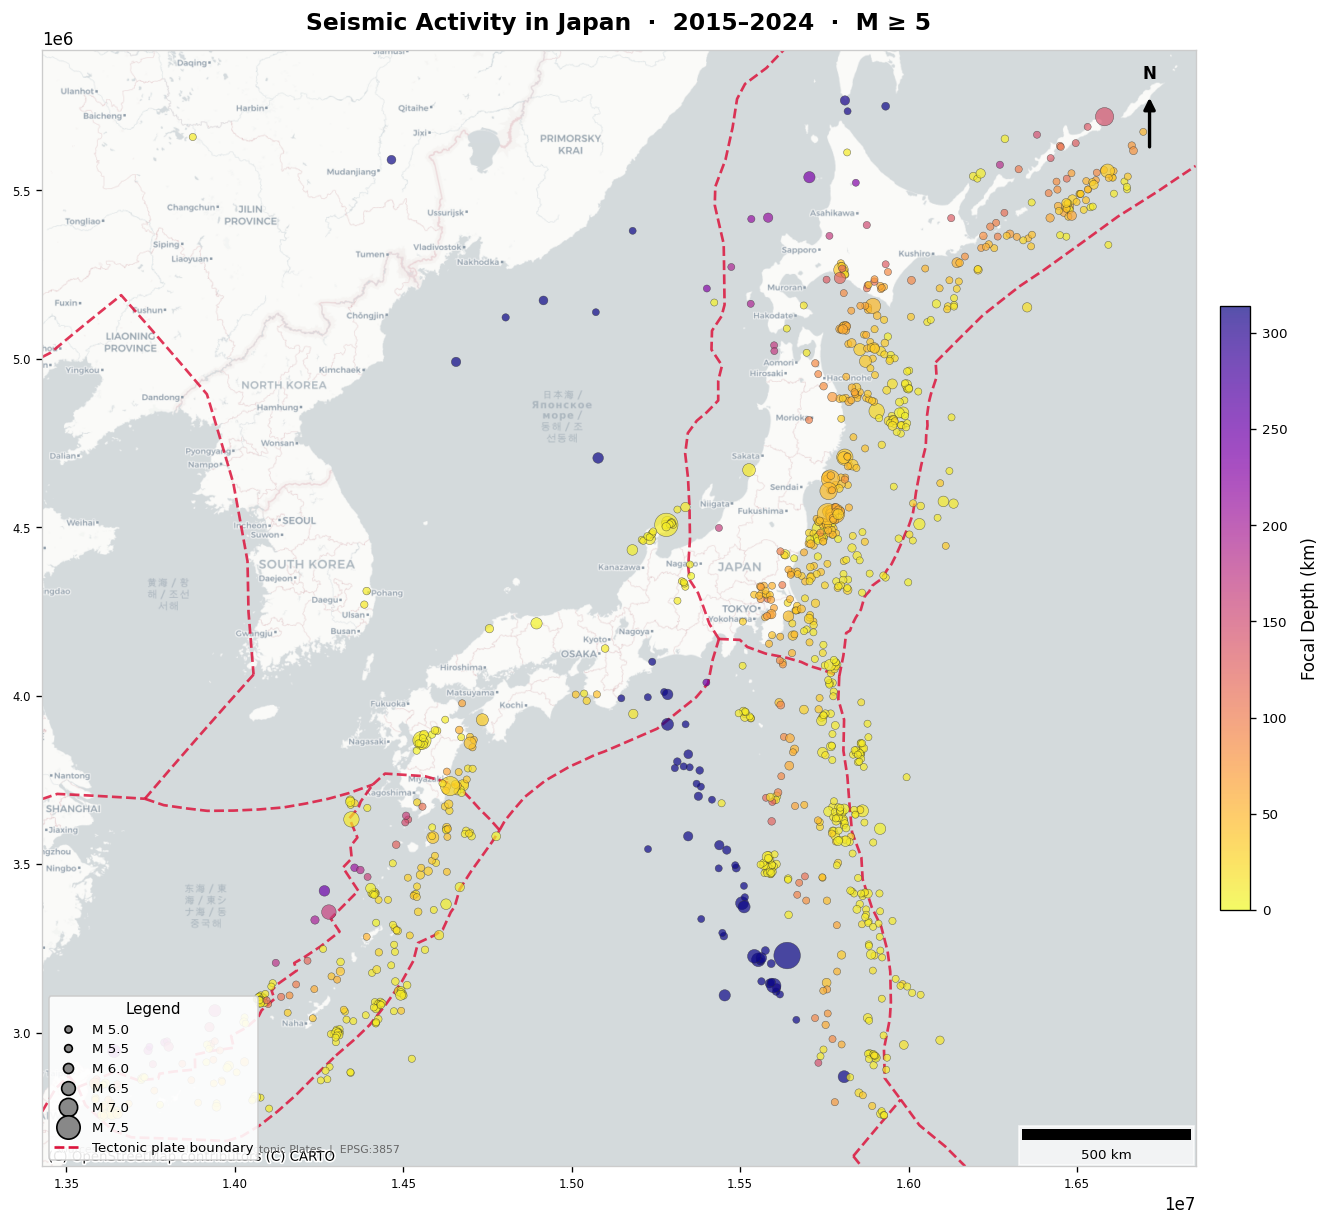

## Static Map-II : SPATIAL DENSITY OF EARTHQUAKE IN JAPAN(2015-2024)<a
href="#Static-Map-II-:-SPATIAL-DENSITY-OF-EARTHQUAKE-IN-JAPAN(2015-2024)"
class="anchor-link">¶</a>

The below map shows the spatial density of earthquakes that occured in
Japan in between 2015 to 2024. Two maps have been plotted in-order to
distinguish the activies (a) between 2015-2019, resulting in 498 events
(b) between 2020-2024, resulting in 579 events with clear representation
of the areas where it was the highest and lowest as comparatively. For
better understanding the boundary of Japan as well as the tectonic plate
positioning has also been depicted.

In \[5\]:

    # Static map2
    def static_map_2(df, output="static_map2_kde.png"):
        fig = plt.figure(figsize=(18, 10), facecolor="white")
        fig.suptitle(
            "Spatial Density of Earthquakes in Japan  ·  M ≥ 5  ·  2015–2024",
            fontsize=16, fontweight="bold", y=0.97, color="#1a1a1a",
        )

        periods  = [("2015–2019", 2015, 2019), ("2020–2024", 2020, 2024)]
        mag_bins = [
            (5.0, 5.9, "M 5.0–5.9", "#4daf4a", 12),
            (6.0, 6.9, "M 6.0–6.9", "#ff7f00", 28),
            (7.0, 9.9, "M ≥ 7.0",   "#e41a1c", 70),
        ]

        # Japan boundary
        japan = None
        try:
            world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
            japan = world[world["name"] == "Japan"]
            print(f"[Japan] Loaded ✓")
        except Exception as e:
            try:
                url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson"
                world = gpd.read_file(url)
                japan = world[world["NAME"] == "Japan"]
                
            except Exception as e2:
                print(f"[Japan] Unavailable: {e2}")

        # Plate boundaries
        plates = None
        try:
            plates = gpd.read_file(
                "https://raw.githubusercontent.com/fraxen/tectonicplates/"
                "master/GeoJSON/PB2002_boundaries.json"
            )

        except Exception as e:
            print(f"[Plates] Unavailable: {e}")

        for col, (label, yr_lo, yr_hi) in enumerate(periods):
            sub = df[(df["year"] >= yr_lo) & (df["year"] <= yr_hi)]
            ax  = fig.add_subplot(1, 2, col + 1)
            ax.set_facecolor("#d6eaf8")
            ax.set_xlim(122, 150)
            ax.set_ylim(24,  46)

            # KDE density raster 
            if len(sub) > 10:
                xs, ys = sub["longitude"].values, sub["latitude"].values
                xg, yg = np.mgrid[122:150:300j, 24:46:300j]
                z = gaussian_kde(
                    np.vstack([xs, ys]), bw_method=0.08
                )(np.vstack([xg.ravel(), yg.ravel()])).reshape(xg.shape)
                ax.imshow(
                    z.T, origin="lower", extent=[122, 150, 24, 46],
                    cmap="YlOrRd", alpha=0.6, aspect="auto", zorder=1,
                )

            # Japan boundary — outline only
            if japan is not None and not japan.empty:
                japan.plot(
                    ax=ax,
                    facecolor="none",
                    edgecolor="#222222",
                    linewidth=1.4,
                    zorder=4,
                    alpha=1.0,
                )

            # Tectonic plate boundaries
            if plates is not None:
                plates.clip_by_rect(122, 24, 150, 46).plot(
                    ax=ax, color="crimson", linewidth=1.4,
                    linestyle="--", alpha=0.8, zorder=3,
                )

            #  Magnitude class scatter
            for lo, hi, lbl, clr, sz in mag_bins:
                s = sub[(sub["magnitude"] >= lo) & (sub["magnitude"] < hi)]
                ax.scatter(
                    s["longitude"], s["latitude"],
                    s=sz, c=clr, alpha=0.75,
                    edgecolors="white", linewidths=0.25,
                    label=f"{lbl}  (n={len(s):,})", zorder=5,
                )

            #  Annotate largest event
            if not sub.empty:
                bq = sub.loc[sub["magnitude"].idxmax()]
                ax.annotate(
                    f"M{bq['magnitude']:.1f}  {bq['datetime'].strftime('%Y-%m-%d')}",
                    xy=(bq["longitude"], bq["latitude"]),
                    xytext=(bq["longitude"] + 2.5, bq["latitude"] - 2),
                    fontsize=8, color="#1a1a1a",
                    arrowprops=dict(arrowstyle="->", lw=1.0, color="#333333"),
                    bbox=dict(boxstyle="round,pad=0.35", fc="white",
                              alpha=0.9, lw=0.6),
                    zorder=6,
                )

            # North arrow
            ax.annotate(
                "", xy=(0.96, 0.96), xytext=(0.96, 0.91),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=2, mutation_scale=14),
            )
            ax.text(
                0.96, 0.97, "N",
                transform=ax.transAxes,
                fontsize=10, fontweight="bold",
                color="black", ha="center", va="bottom",
            )

            ax.set_title(
                f"{label}  ·  n = {len(sub):,} events",
                fontsize=13, fontweight="semibold", pad=8, color="#1a1a1a",
            )
            ax.set_xlabel("Longitude (°E)", fontsize=9, color="#333333")
            ax.set_ylabel("Latitude (°N)",  fontsize=9, color="#333333")
            ax.tick_params(labelsize=8)
            ax.grid(True, lw=0.4, alpha=0.3, color="#aaaaaa", linestyle=":")

            # ── Legend ──
            handles, labels_list = ax.get_legend_handles_labels()
            handles.append(
                Line2D([0],[0], color="crimson", lw=1.4,
                       linestyle="--", label="Plate boundary")
            )
            handles.append(
                Line2D([0],[0], color="#222222", lw=1.4,
                       linestyle="-", label="Japan boundary")
            )
            ax.legend(
                handles=handles, loc="lower right",
                fontsize=8, framealpha=0.9, facecolor="white",
                title="Legend", title_fontsize=8,
            )

            for spine in ax.spines.values():
                spine.set_edgecolor("#cccccc")

        # ── Shared KDE colorbar ──
        cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.65])
        sm = plt.cm.ScalarMappable(cmap="YlOrRd")
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label("Seismic Density (KDE intensity)",
                       fontsize=9, labelpad=10)
        cbar.ax.tick_params(labelsize=7)

        fig.text(
            0.5, 0.01,
            "Sources: USGS FDSN API; PB2002 Tectonic Plates; Natural Earth  |  "
            "KDE bandwidth = 0.08  |  EPSG:4326",
            ha="center", fontsize=7.5, color="#666666",
        )

        plt.tight_layout(rect=[0, 0.03, 0.91, 0.95])
        fig.savefig(output, dpi=180, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.show()
        plt.close()
        

    static_map_2(df)

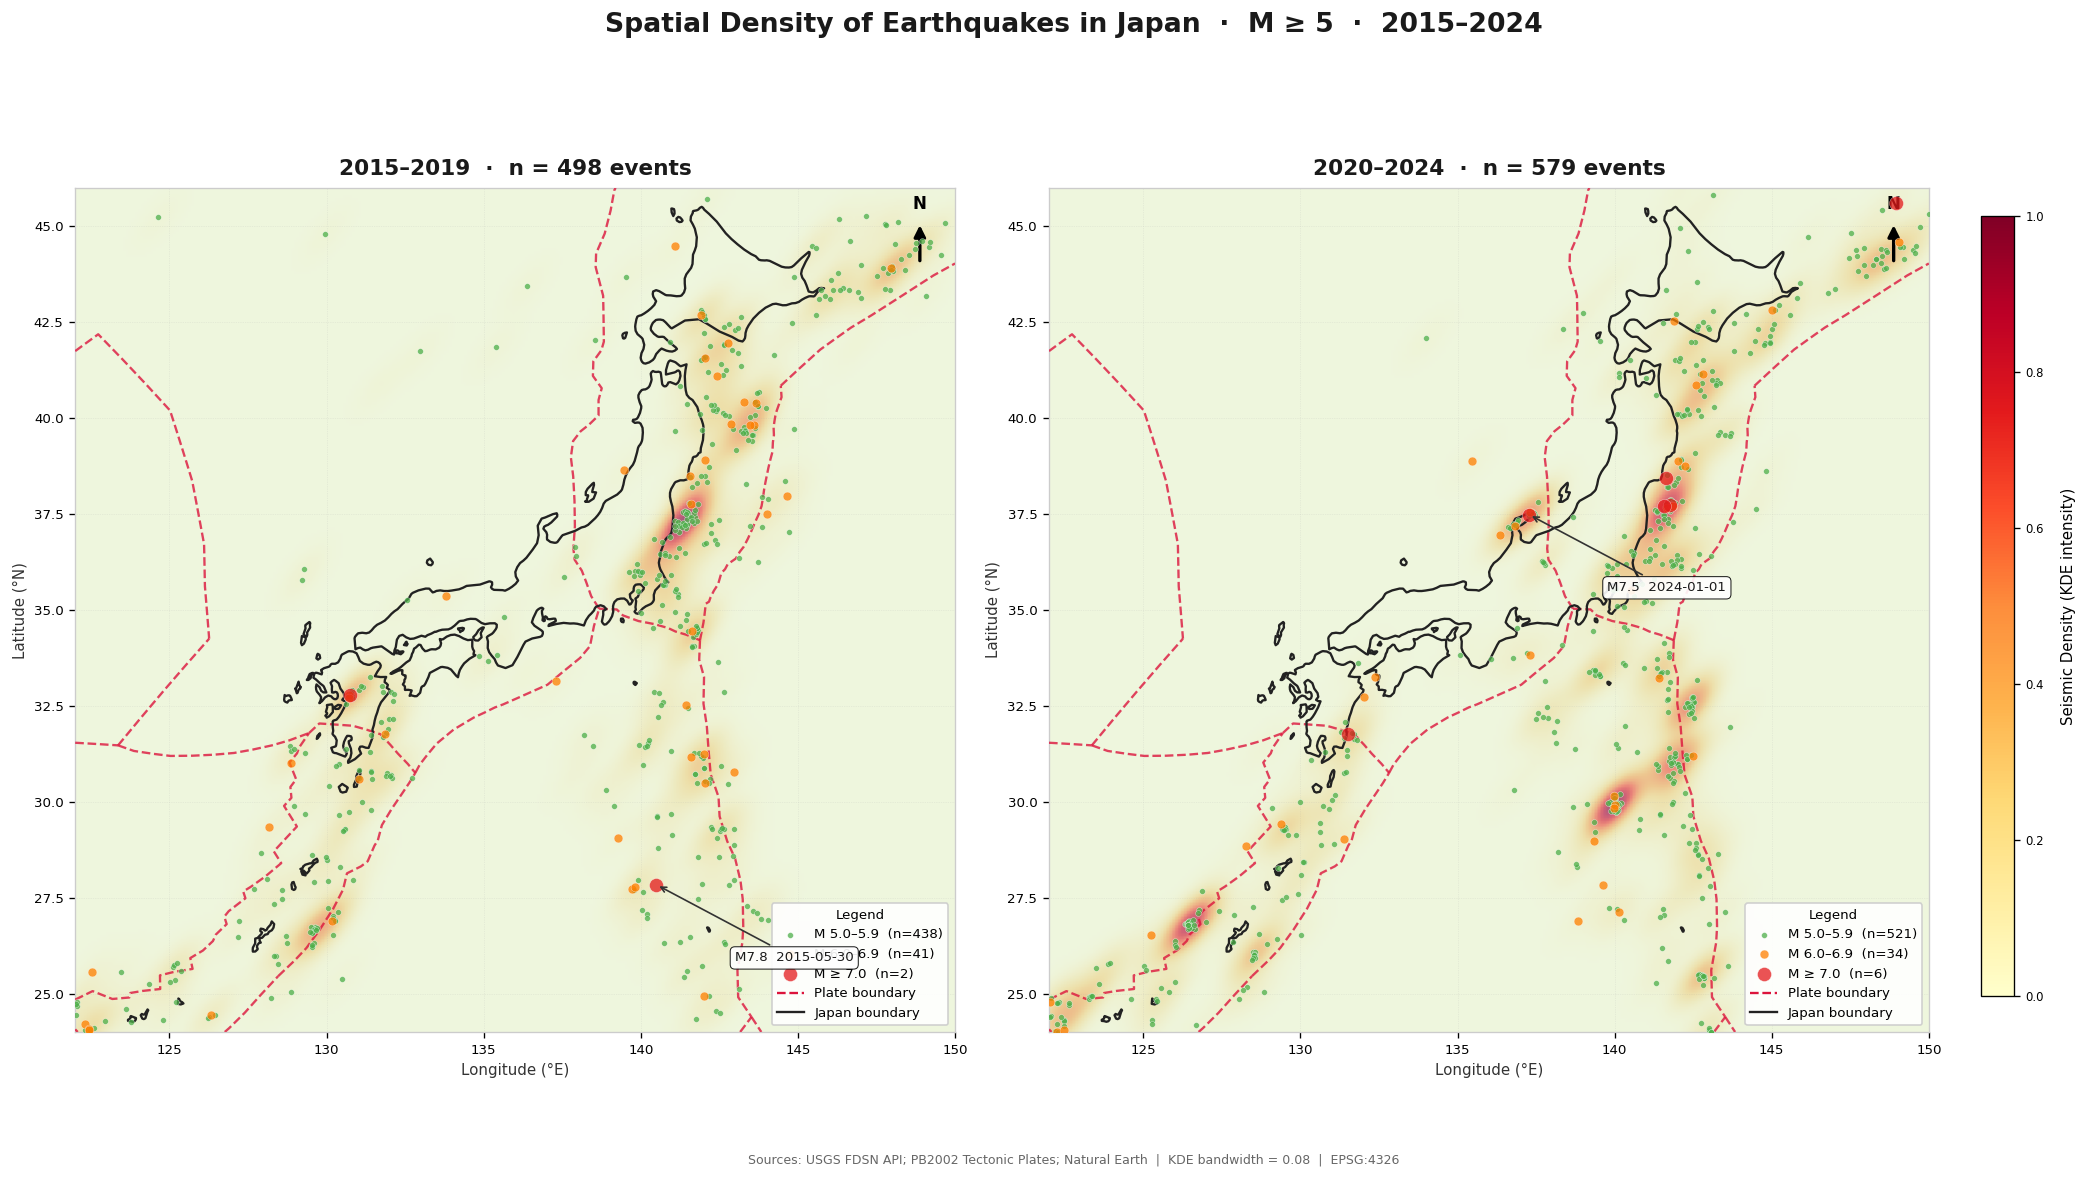

## Data Source<a href="#Data-Source" class="anchor-link">¶</a>

This assessment is based on three spatial datasets, each chosen for its
relevance to the research question and its clear connection to
geographic space.

The main dataset is the USGS Earthquake Hazards Program catalogue, which
can be accessed through the FDSN (International Federation of Digital
Seismograph Networks) Web Service API. This dataset contains
point-geometry earthquake records along with information about them,
such as moment magnitude, focal depth, epicentral coordinates, and
origin time. For this study, events are filtered to M≥5.0 within a
bounding box encompassing the Japanese archipelago (24°–46°N,
122°–150°E) for the period 2015–2024. Magnitude is the main hazard
variable, and focal depth is very important for telling shallow crustal
earthquakes (≤70 km) apart from intermediate and deep events that happen
when slabs slide under the Earth's surface. This is a key structural
feature of Japan's tectonic setting.

The second dataset is the PB2002 tectonic plate boundary dataset (Bird,
2003), which we got from a public GitHub repository as a GeoJSON
FeatureCollection. This polyline dataset shows the geometric locations
of all the major plate boundaries around the world. It is used here as a
structural overlay to help explain why earthquakes happen in clusters.
Using spatial proximity analysis, we can directly connect the plate
boundaries to the earthquake point data. Events consistently cluster
within 50–100 km of subduction boundaries, which supports the structural
interpretation.

The third dataset is the Natural Earth country boundaries dataset, which
is used to draw Japan's coastline and island shapes. This gives us a
spatial reference frame that we can use to read seismic patterns. This
is important for letting people know whether the hazard is concentrated
along the Pacific coast, the Sea of Japan margin, or the Ryukyu island
arc. The coordinates in all three datasets are in EPSG:4326 (WGS84),
which makes sure that they are the same across all layers.

In \[7\]:

    # complete API request function with inline documentation 

    def fetch_earthquakes(start_date, end_date, min_magnitude):
        """
        Custom USGS FDSN REST API request function.

        Architecture:
        ------------
        This function acts as the CLIENT in a client-server model.
        It constructs an HTTPS GET request with spatial bounding-box
        and attribute filters as URL query parameters. The USGS server
        processes and filters the data server-side, returning only
        matching records as a GeoJSON FeatureCollection. This approach
        minimises data transfer — instead of downloading the full global
        catalogue (~1M+ events), only the filtered subset is returned.

        API Endpoint:
        ------------
        https://earthquake.usgs.gov/fdsnws/event/1/query
        
        Key parameters:
          format       → geojson (machine-readable spatial format)
          starttime    → ISO 8601 date string
          endtime      → ISO 8601 date string
          minmagnitude → lower magnitude threshold
          minlatitude, maxlatitude, minlongitude, maxlongitude
                       → spatial bounding box (Japan region)
          orderby      → time-asc (chronological ordering)

        Returns: pd.DataFrame with cleaned earthquake records
        """
        url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
        params = {
            "format":       "geojson",
            "starttime":    start_date,
            "endtime":      end_date,
            "minmagnitude": min_magnitude,
            "minlatitude":  24,  "maxlatitude":  46,
            "minlongitude": 122, "maxlongitude": 150,
            "orderby":      "time-asc",
        }

        print(f"Requesting: M≥{min_magnitude}, {start_date} → {end_date}")
        r = requests.get(url, params=params, timeout=90)
        r.raise_for_status()
        features = r.json()["features"]
        print(f"Raw features returned: {len(features):,}")

        # ── Parse GeoJSON features into flat records ──
        records = []
        for f in features:
            p = f["properties"]
            c = f["geometry"]["coordinates"]  # [lon, lat, depth_km]
            records.append({
                "longitude":  c[0],
                "latitude":   c[1],
                "depth":      c[2],           # focal depth in km
                "magnitude":  p["mag"],
                "place":      p.get("place", ""),
                "time":       p["time"],       # Unix epoch milliseconds
                "event_type": p.get("type", "earthquake"),
            })

        df = pd.DataFrame(records)

        # Data cleaning
        df["datetime"] = pd.to_datetime(df["time"], unit="ms")
        df["year"]     = df["datetime"].dt.year

        # Remove non-earthquake events (quarry blasts, explosions)
        df = df[df["event_type"] == "earthquake"]

        # Drop records with missing spatial or magnitude data
        df = df.dropna(subset=["magnitude", "latitude", "longitude"])

        # Exploratory summary
        print(f"\nCleaned dataset: {len(df):,} events")
        print(f"Magnitude range : {df['magnitude'].min():.1f} – {df['magnitude'].max():.1f}")
        print(f"Depth range     : {df['depth'].min():.1f} – {df['depth'].max():.1f} km")
        print(f"Date range      : {df['datetime'].min().date()} → {df['datetime'].max().date()}")
        print(f"Events per year :\n{df['year'].value_counts().sort_index()}")

        return df

    # Run the API request 
    df = fetch_earthquakes("2015-01-01", "2024-12-31", min_magnitude=5.0)

    # Build GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.longitude, df.latitude),
        crs="EPSG:4326",
    )

    # Quick data exploration
    print("\nColumn types:")
    print(df.dtypes)

    print("\nMagnitude distribution by class:")
    print(pd.cut(df["magnitude"],
                 bins=[5,5.5,6,6.5,7,9.9],
                 labels=["M5.0–5.5","M5.5–6.0","M6.0–6.5","M6.5–7.0","M7.0+"]
                 ).value_counts().sort_index())

    print("\nDepth class distribution:")
    print(pd.cut(df["depth"],
                 bins=[0,70,300,700],
                 labels=["Shallow (0–70km)",
                         "Intermediate (70–300km)",
                         "Deep (300–700km)"]
                 ).value_counts().sort_index())

    Requesting: M≥5.0, 2015-01-01 → 2024-12-31
    Raw features returned: 1,080

    Cleaned dataset: 1,077 events
    Magnitude range : 5.0 – 7.8
    Depth range     : 2.9 – 664.0 km
    Date range      : 2015-01-04 → 2024-12-27
    Events per year :
    year
    2015    101
    2016    139
    2017     86
    2018     90
    2019     82
    2020     92
    2021    104
    2022    141
    2023    145
    2024     97
    Name: count, dtype: int64

    Column types:
    longitude            float64
    latitude             float64
    depth                float64
    magnitude            float64
    place                 object
    time                   int64
    event_type            object
    datetime      datetime64[ns]
    year                   int32
    dtype: object

    Magnitude distribution by class:
    magnitude
    M5.0–5.5    575
    M5.5–6.0    173
    M6.0–6.5     51
    M6.5–7.0     12
    M7.0+         5
    Name: count, dtype: int64

    Depth class distribution:
    depth
    Shallow (0–70km)           903
    Intermediate (70–300km)    116
    Deep (300–700km)            58
    Name: count, dtype: int64

## API<a href="#API" class="anchor-link">¶</a>

The USGS FDSN Web Service is a RESTful API, which means that all
interactions are stateless HTTPS requests that return responses that are
complete on their own. The API endpoint takes query parameters right in
the URL, so it's easy to make programmatic requests without needing
authentication tokens or API keys.

The fetch_earthquakes() function handles the whole request process. It
builds the parameter dictionary, sends an HTTPS GET request using
Python's requests library, parses the returned GeoJSON
FeatureCollection, and flattens nested JSON structures into a pandas
DataFrame that can be used for analysis and visualisation.

The API gives back GeoJSON, which is great for spatial work. Each
earthquake is shown as a Point Feature with coordinates \[longitude,
latitude, depth\] in the geometry field and attributes (magnitude,
place, time, event type) in the properties field. GeoPandas uses a
GeoDataFrame model that is very similar to this structure. Each row is a
georeferenced observation.

This DataFrame is what the interactive Folium map uses to create its
CircleMarkers. The StepColormap uses the radius of each CircleMarker to
show how big it is and the colour to show what size class it is. The
popup content comes from the place, datetime, depth, and magnitude
fields that were parsed during the API call. This shows an end-to-end
pipeline from raw API response to rendered web map.

In \[8\]:

    # Interactive follium map
    def interactive_map(df, output="interactive_map.html"):
        m = folium.Map(
            location=[36.5, 136.5], zoom_start=5,
            tiles=None, prefer_canvas=True,
        )

        # Tile layers
        folium.TileLayer("CartoDB dark_matter",
                         name="🌑 Dark (CartoDB)",
                         attr="© CartoDB © OSM").add_to(m)
        folium.TileLayer("CartoDB positron",
                         name="🌕 Light (CartoDB)",
                         attr="© CartoDB © OSM").add_to(m)
        folium.TileLayer(
            tiles="https://server.arcgisonline.com/ArcGIS/rest/services/"
                  "World_Imagery/MapServer/tile/{z}/{y}/{x}",
            name="🛰 Satellite (Esri)", attr="Tiles © Esri",
        ).add_to(m)

        # Magnitude colourmap
        colormap = StepColormap(
            ["#ffffb2","#fecc5c","#fd8d3c","#f03b20","#bd0026","#67000d"],
            vmin=5, vmax=8,
            index=[5, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0],
            caption="Earthquake Magnitude",
        )
        colormap.add_to(m)

        # Feature groups
        fg_all     = folium.FeatureGroup(name="⚪ All Events (circles)",  show=True)
        fg_major   = folium.FeatureGroup(name="⭐ Major Events M ≥ 6.5",  show=True)
        fg_cluster = folium.FeatureGroup(name="🔵 Clustered Markers",     show=False)
        fg_heat    = folium.FeatureGroup(name="🔥 Heatmap (density)",     show=False)

        cluster   = MarkerCluster(options={"maxClusterRadius": 40,
                                           "disableClusteringAtZoom": 8})
        heat_data = []

        for _, row in df.iterrows():
            lat, lon  = row["latitude"],  row["longitude"]
            mag, dep  = row["magnitude"], row["depth"]
            place     = row.get("place", "")
            dt        = str(row["datetime"])[:10]
            color     = colormap(min(max(mag, 5), 8))
            radius    = max(3, (mag - 4.5) ** 2.2)

            popup_html = f"""
            <div style="font-family:Arial;font-size:13px;width:220px;">
              <b style="font-size:16px;color:#c0392b;">M {mag:.1f}</b>
              <hr style="margin:4px 0;border-color:#ddd;">
              <table style="width:100%;">
                <tr><td style="color:#666;">📍</td><td>{place}</td></tr>
                <tr><td style="color:#666;">📅</td><td>{dt}</td></tr>
                <tr><td style="color:#666;">⬇️</td><td>{dep:.1f} km depth</td></tr>
                <tr><td style="color:#666;">🌐</td>
                    <td>{lat:.3f}°N, {lon:.3f}°E</td></tr>
              </table>
            </div>"""

            folium.CircleMarker(
                [lat, lon], radius=radius,
                color=color, fill=True, fill_color=color,
                fill_opacity=0.65, weight=0.6,
                popup=folium.Popup(popup_html, max_width=240),
                tooltip=f"M{mag:.1f} | {dep:.0f}km | {dt}",
            ).add_to(fg_all)

            if mag >= 6.5:
                folium.Marker(
                    [lat, lon],
                    popup=folium.Popup(popup_html, max_width=240),
                    tooltip=f"⭐ M{mag:.1f} — {place}",
                    icon=folium.Icon(color="red", icon="star", prefix="fa"),
                ).add_to(fg_major)

            folium.CircleMarker(
                [lat, lon], radius=6, color=color,
                fill=True, fill_color=color, fill_opacity=0.8,
                popup=folium.Popup(popup_html, max_width=240),
            ).add_to(cluster)

            heat_data.append([lat, lon, mag])

        cluster.add_to(fg_cluster)
        HeatMap(
            heat_data, min_opacity=0.25, radius=14, blur=12,
            gradient={0.2:"#313695", 0.45:"#74add1",
                      0.65:"#fee090", 0.85:"#f46d43", 1.0:"#a50026"},
        ).add_to(fg_heat)

        for fg in [fg_all, fg_major, fg_cluster, fg_heat]:
            fg.add_to(m)

        folium.LayerControl(collapsed=False).add_to(m)
        Fullscreen(position="topright").add_to(m)
        MiniMap(toggle_display=True, position="bottomright").add_to(m)

        # Floating info panel
        m.get_root().html.add_child(folium.Element("""
        <div style="position:fixed;top:10px;left:60px;z-index:1000;
                    background:rgba(13,17,23,0.9);color:#e0e0e0;
                    padding:14px 18px;border-radius:8px;font-family:Arial;
                    font-size:13px;border:1px solid #444;max-width:250px;
                    box-shadow:0 4px 16px rgba(0,0,0,0.5);">
          <b style="font-size:15px;color:#fd8d3c;">🗾 Japan Seismic Map</b>
          <br><span style="font-size:11px;color:#aaa;">2015–2024 · M ≥ 5.0</span>
          <hr style="border-color:#444;margin:8px 0;">
          <b>Layers (toggle top-right):</b><br>
          ⚪ Circles — magnitude &amp; depth<br>
          ⭐ Stars — major M ≥ 6.5 events<br>
          🔵 Clusters — auto-grouped<br>
          🔥 Heatmap — event density<br>
          <hr style="border-color:#444;margin:8px 0;">
          Click any marker for full details.
        </div>"""))

        m.save(output)
        return m

    m = interactive_map(df)
    m

Out\[8\]:

<span style="color:#565656">Make this Notebook Trusted to load map: File
-\> Trust Notebook</span>

## MAP 3: Interactive Folium Map<a href="#MAP-3:-Interactive-Folium-Map" class="anchor-link">¶</a>

Folium is a Python wrapper for the Leaflet.js JavaScript library that
makes the interactive map. Leaflet works completely on the client side.
Once the HTML file is saved, all map interactions (panning, zooming,
toggling layers, and popups) happen in the browser without needing a
server. This makes the map easy to move and share as a single HTML file.

There are three basemap tilesets that you can switch between on the map:
CartoDB Dark Matter, CartoDB Positron and Esri World Imagery were used
as XYZ tiles and were only loaded when the viewport and zoom level were
needed. This shows the client-server tile architecture that is important
for modern web mapping. The browser only asks for the tiles that are
visible in the current view and at the right resolution for the current
zoom level.

Four groups of features that can be turned on and off give you
analytical freedom. The default circle layer uses marker radius to show
magnitude and a stepped colour map (yellow → dark red, M5–M8) to show
colour, making it easy for users to tell how bad an event is right away.
The star marker layer separates major events (M≥6.5) so that the most
dangerous ones can be found quickly. The cluster layer puts together
dense point clouds at low zoom levels, making them easier to read. The
heatmap layer shows regional density patterns that are the same as those
found in the static maps' KDE analysis. It does this by using a
blue-to-red gradient weighted by magnitude. Each marker has a rich HTML
popup that shows the location, date, depth, and coordinates. This lets
you explore the dataset at the event level.

## Conclusion<a href="#Conclusion" class="anchor-link">¶</a>

This assignment has shown how geovisualization tools can turn a raw
earthquake catalogue into a clear story about Japan's seismic hazard.
The study used the USGS FDSN API along with GeoPandas, Matplotlib, and
Folium to make three visualisations that work well together: a dot map
that shows magnitude and depth, a KDE temporal comparison that shows how
density changed between 2015 and 2019 and between 2020 and 2024, and a
fully interactive web map that lets you explore events at the event
level. These maps show that plate boundary geometry and seismic
clustering are related, and they also show that activity in the Noto
Peninsula region picked up during the second period. This is important
for hazard assessment and community resilience planning in Japan.

# References<a href="#References" class="anchor-link">¶</a>

1.Norio, O., Ye, T., Kajitani, Y. et al. The 2011 eastern Japan great
earthquake disaster: Overview and comments. Int J Disaster Risk Sci 2,
34–42 (2011). <https://doi.org/10.1007/s13753-011-0004-9>

2.Tatsuo Aoki, Yoshihiro Fukumoto, Satoshi Yasuda, Yasuhiko Sakata,
Kenta Ito, Jun Takahashi, Satoshi Miyata, Ichiro Tsuji, Hiroaki
Shimokawa, The Great East Japan Earthquake Disaster and cardiovascular
diseases, European Heart Journal, Volume 33, Issue 22, November 2012,
Pages 2796–2803, <https://doi.org/10.1093/eurheartj/ehs288>

3.P. Bailly du Bois, P. Laguionie, D. Boust, I. Korsakissok, D. Didier,
B. Fiévet, Estimation of marine source-term following Fukushima Dai-ichi
accident, Journal of Environmental Radioactivity, Volume 114, 2012,
Pages 2-9, ISSN 0265-931X,
<https://doi.org/10.1016/j.jenvrad.2011.11.015>

4.Stephen Batsford, The Great East Japan Earthquake and Tsunami Viewed
from Western Europe: How Has Fukushima Influenced the Peaceful Use of
Atomic Energy in Europe?, The Tohoku Journal of Experimental Medicine,
2013, Volume 229, Issue 4, Pages 239-244, Released on J-STAGE March 29,
2013, Online ISSN 1349-3329, Print ISSN 0040-8727,
<https://doi.org/10.1620/tjem.229.239>,
<https://www.jstage.jst.go.jp/article/tjem/229/4/229_239/_article/-char/en>

5.Japan's worst-ever nuclear accident displaced more than 100,000
people. Many could now safely return home. Yet mistrust of the
government prolongs their exile. SN - 1476-4687 UR -
<https://doi.org/10.1038/483138a>

6.Impacts of the Fukushima Nuclear Power Plants on Marine Radioactivity.
<https://doi.org/10.1021/es202816c>

7.Parental Subjective Disaster Experiences and Behavioral Problems in
Children Born After the Great East Japan Earthquake: An
Intergenerational Perspective
<https://doi.org/10.1007/s10578-026-01961-4>

8.Ryo Saito, Ryota Takano, Pradytia Putri Pertiwi, Mufidatun Khoiriyah,
Akihiro Aotani, Hiroyuki Miura, Toshiaki Muramoto, Osamu Murao,
Spatio-Temporal Dynamics of Collective Disaster Event Cognition in the
Digital Sphere: A Long-Term Case Study of the Great East Japan
Earthquake (2011–2025), Journal of Disaster Research, 2026, 21 巻, 1 号,
p. 181-200, 公開日 2026/02/01, Online ISSN 1883-8030, Print ISSN
1881-2473, <https://doi.org/10.20965/jdr.2026.p0181>,
<https://www.jstage.jst.go.jp/article/jdr/21/1/21_181/_article/-char/ja>,
抄録:

9.The effects of disaster experiences on social isolation and related
factors remain unclear. Using longitudinal data, this study aimed to
identify new social isolation and its associated factors after the Great
East Japan Earthquake (GEJE), which occurred on March 11, 2011. SN -
1471-2458 UR - <https://doi.org/10.1186/s12889-025-23778-x>

10.Evaluate the capacity of Japanese spatial planning system for hazards
integration realities and (f)acts: a pre-post the great east Japan
Earthquake in Fukushima,
2011<https://doi.org/10.1007/s42797-024-00102-1>

In \[ \]: